In [2]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Five-layer architecture: interface examples

This notebook is the executable usage guide for the modular architecture. The raw and standard data layers are implemented; later sections define the intended public interfaces.

In [3]:
from pathlib import Path
import gc

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

from src.raw import RawDataManager
from src.standard import DATASET_IDS, StandardDataManager
from src.mapping import SpatiotemporalMappingManager
from src.case import PowerSystemCaseManager
from src.app import UnitCommitmentApplication
from src.visualization import configure_matplotlib, resolve_plot_settings

_plot_font = configure_matplotlib(resolve_plot_settings())
plt.ioff()  # Figures are shown only by an explicit display() call.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

data_root = project_root / "data"

In [4]:
raw_data = RawDataManager(project_root / "config/raw_data_sources.csv", data_root)
_catalog = raw_data._catalog
_check = raw_data.check()
_prepare = raw_data.prepare()
_source_id = "gem_integrated_power"
_file_path = raw_data.get_file(_source_id)
display(_prepare)

,provider,acquisition_method,file_format,local_path,detected_path,available,size_bytes,checksum,status,download_instructions
source_id,,,,,,,,,,
osm_china_pbf,Geofabrik/direct OSM export,direct,pbf,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/osm/china-latest.osm.pbf,<NA>,True,1560217727,,available,Automatic: prepare downloads the current china-latest.osm.pbf from Geofabrik.
gem_integrated_power,Global Energy Monitor,manual,xlsx,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/Global-Integrated-Power-March-2026-II.xlsx,<NA>,True,23337385,,available,"Manual: open the GEM page, select Download data, complete the official form, and save the workbook under data/ using its original or configured filename."
doe_storage,Sandia National Laboratories,manual,json,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/doe_global_energy_storage_database_2022.json,<NA>,True,7436775,,available,"Manual: open the Sandia GESDB project page, accept its terms of use, export projects to JSON, and save the file under data/ using its original or configured filename."
provincial_hourly_load,Figshare,figshare_api,xlsx,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/china_provincial_hourly_load_2015_2024.xlsx,<NA>,True,41867984,bf730a545bc297b20d6a7ff93571992a,available,Automatic: prepare resolves Data output.xlsx through the Figshare article API and downloads it.
worldpop_population,WorldPop,direct,tif,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/chn_ppp_2020_1km_aggregated_unadj.tif,<NA>,True,49445858,,available,Automatic: prepare downloads the GeoTIFF directly from the WorldPop file index.
era5_china_2024,Copernicus Climate Data Store,atlite_cds,nc,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/era5/era5_china_2024.nc,<NA>,True,12209805208,,available,"API: accept the ERA5 licence, configure ~/.cdsapirc, then run RawDataManager.prepare('era5_china_2024'); atlite submits serial monthly requests and validates the completed cutout."
province_boundaries,DataV,direct,geojson,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/china_provinces_datav_original.geojson,<NA>,True,582522,,available,Automatic: prepare downloads the original province GeoJSON; geometry cleaning belongs to the standard data layer.
offshore_wind_potential_eap,World Bank ESMAP,direct,zip,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/eap_technical_potential_offshore_wind.zip,<NA>,True,7940083,f8b8f1f089cff3e6c1e4f2ffc5bca93e,available,Automatic: prepare downloads the CC BY 4.0 regional Shapefile archive; spatial standardization filters ISO_Ter1=CHN and dissolves both foundation zones into one marine zone.
china_eez_marine_regions,Marine Regions / VLIZ,direct,geojson,/Users/jiang/Documents/Codex/nature-plan-paper/GridX/data/china_eez_v12.geojson,<NA>,True,2387518,,available,"Automatic: prepare queries the official Marine Regions WFS for sovereign code CHN and pol_type=200NM. Use as a reproducible modelling boundary, not as an adjudication of disputed maritime claims."


In [5]:
standard_manager = StandardDataManager(project_root / "config/standard_data.toml", raw_data=raw_data)
_check = standard_manager.check()
_build = standard_manager.build()
_id = "storage"
_load = standard_manager.load(_id)
_schema = standard_manager.schema(_id)
display(dir(standard_manager.load()))

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__replace__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'close',
 'config',
 'generator',
 'load',
 'network',
 'parameter',
 'plot',
 'population',
 'resource',
 'schema',
 'spatial',
 'storage']

In [6]:
_para = standard_manager.load("parameter")
_count = _para.count()
_rules = _para.matching_rules
resolved, candidates = _para.resolve(
    standard_manager.load("generator").iloc[10000],
    ["minimum_output_pu", "ramp_up_pu_per_hour"],
    dataset_id="generator",
    include_candidates=True,
)
display(_rules)

,rank,criterion,direction,description,configured_value
0,-1,ineligible,excluded,No named candidate passes all applicability constraints.,<NA>
1,0,eligible,accepted,"A single named candidate passes dataset, asset selectors, capacity, voltage, time, location, scenario, and selector_json constraints.",<NA>
2,1,exact uid,preferred,Prefer applies_to_uid equal to the target asset uid.,<NA>
3,2,specificity,higher first,Prefer the candidate matching more explicit conditions.,<NA>
4,3,priority,lower first,Apply the optional per-call source priority.,<NA>
5,4,quality,configured order,Apply quality_order from standard_data.toml.,official_observation > source > standard_type_proxy > derived > generic > interpolated > proxy > low > model_default
6,5,observed time,latest first,Prefer the most recently observed eligible record.,<NA>
7,6,equal values,equivalent,Equal-rank candidates have equivalent values and units.,<NA>
8,7,ambiguous,unresolved,Equal-rank candidates conflict in value or unit.,<NA>


In [7]:
mapping_manager = SpatiotemporalMappingManager(project_root / "config/mapping.toml", standard_manager)
_check = mapping_manager.check()
_build = mapping_manager.build()
mapped_data = mapping_manager.load()
_id = "network"
_schema = mapping_manager.schema(_id)
display(dir(mapped_data))

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__replace__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'close',
 'config',
 'generator',
 'load',
 'network',
 'parameter',
 'plot',
 'population',
 'resource',
 'schema',
 'spatial',
 'storage']

In [8]:
case_manager = PowerSystemCaseManager(project_root / "config/case.toml", mapped_data=mapped_data)
_check = case_manager.check()
_build = case_manager.build()
case_data = case_manager.load()
display(case_data.config)

{'general': {'output_root': 'outputs/case',
  'metric_crs': '+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105 +datum=WGS84 +units=m +no_defs',
  'random_seed': 42},
 'network': {'minimum_voltage_kv': 500.0,
  'maximum_voltage_kv': 2000.0,
  'missing_status_is_active': True,
  'bus_statuses': ['operating',
   'operational',
   'active',
   'in_service',
   'in_use'],
  'branch_statuses': ['operating',
   'operational',
   'active',
   'in_service',
   'in_use'],
  'transformer_statuses': ['operating',
   'operational',
   'active',
   'in_service',
   'in_use'],
  'converter_statuses': ['operating',
   'operational',
   'active',
   'in_service',
   'in_use'],
  'bus_subclasses': ['station_bus']},
 'assets': {'generator': {'statuses': ['operating',
    'operational',
    'active',
    'in_service',
    'in_use'],
   'minimum_capacity_mw': 10.0,
   'maximum_capacity_mw': 1000000.0},
  'storage': {'statuses': ['operating',
    'operational',
    'active',
    'in_service',
    'in_use'],

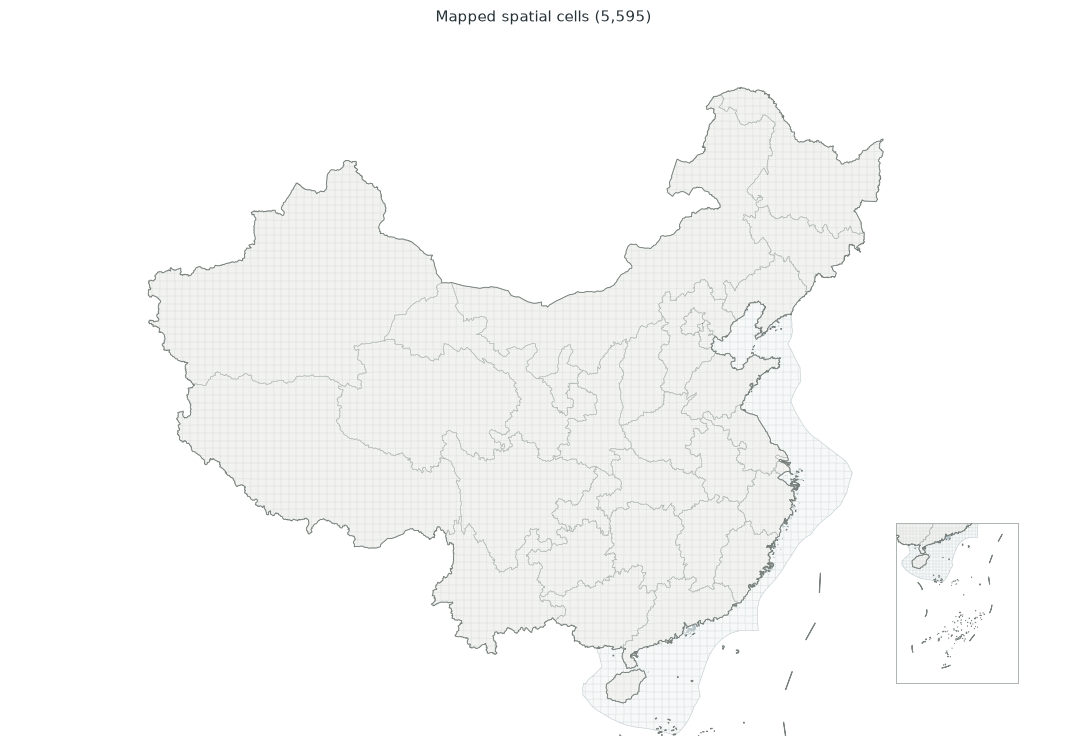

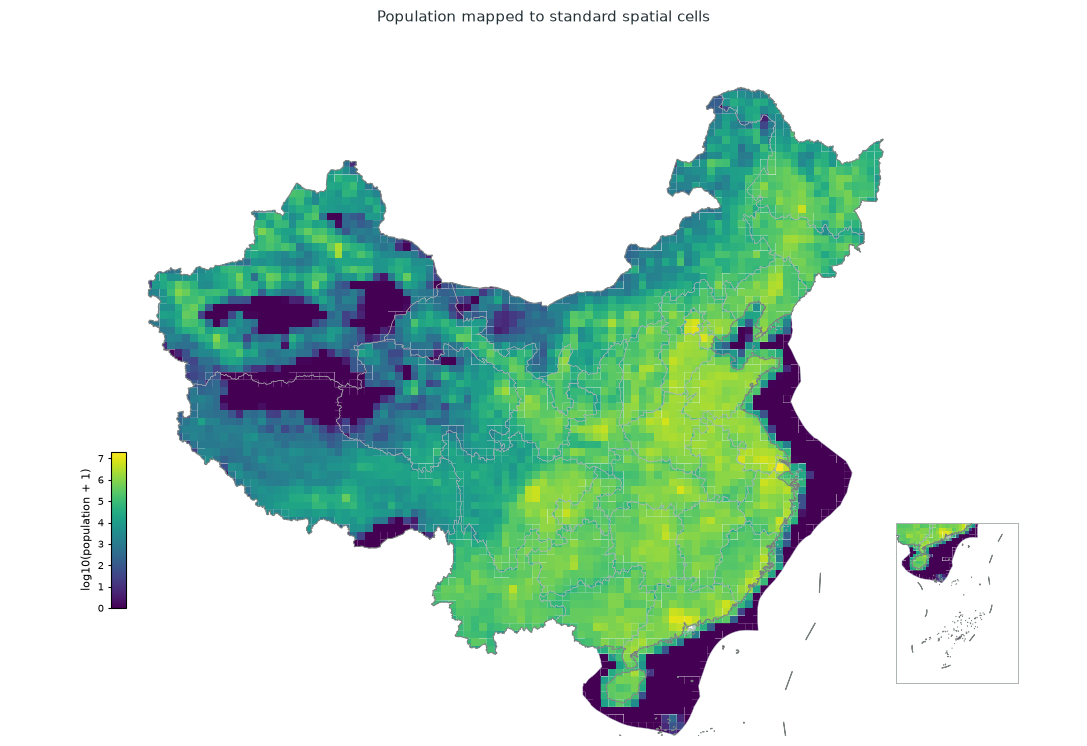

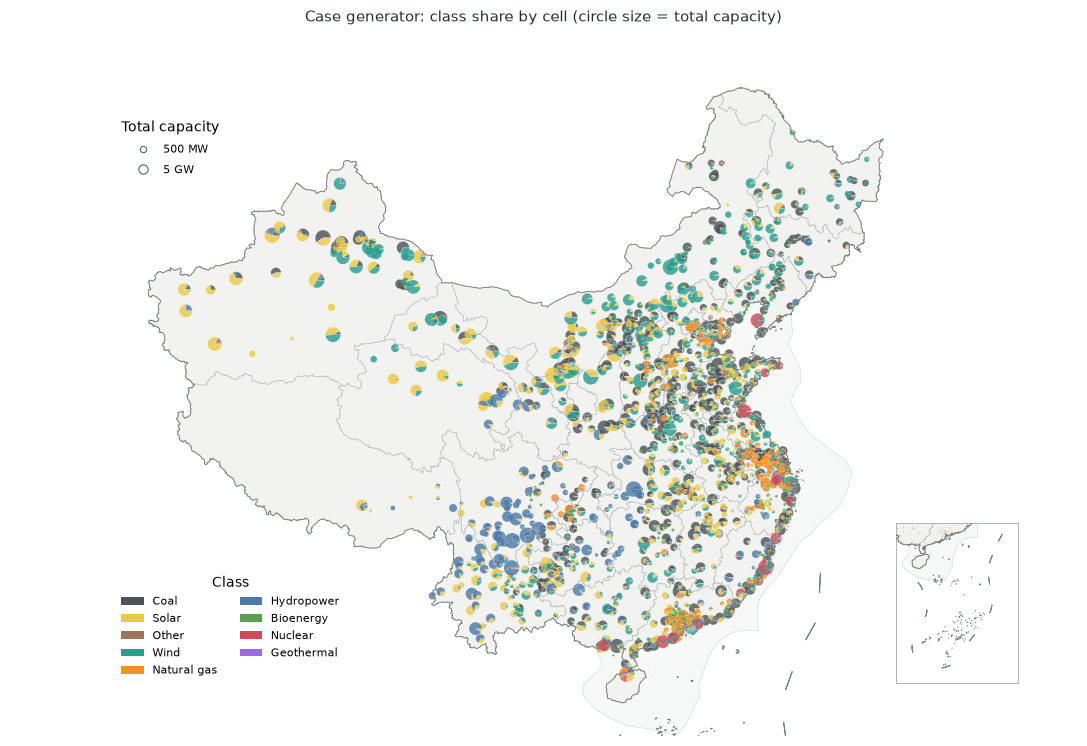

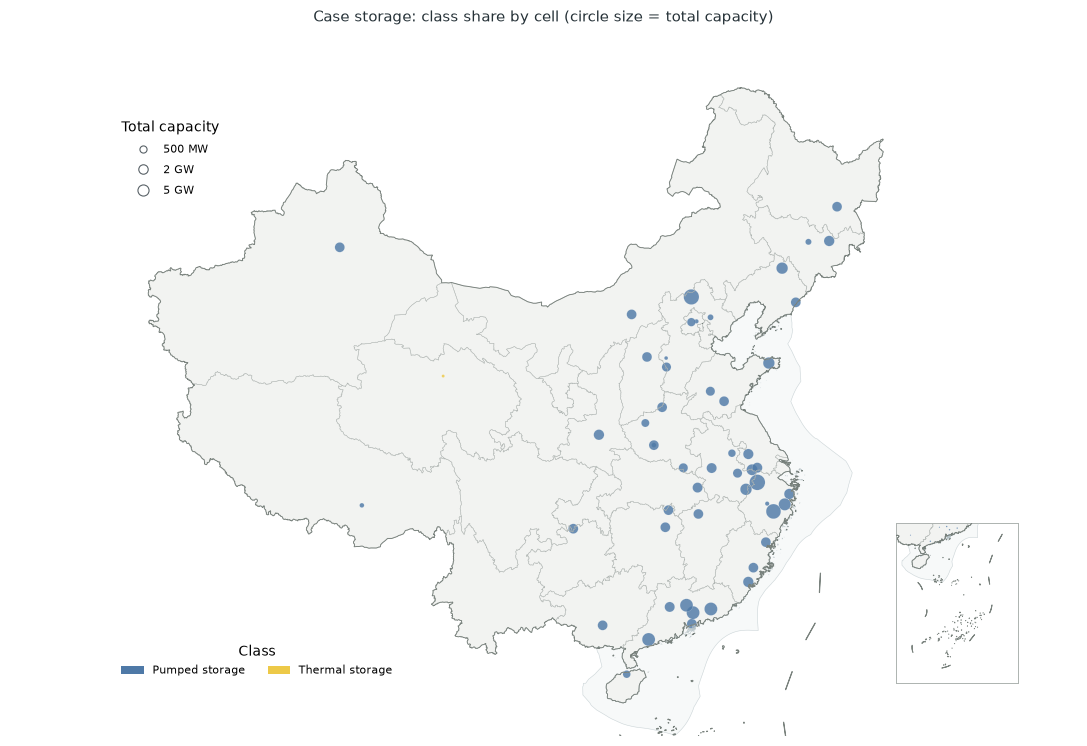

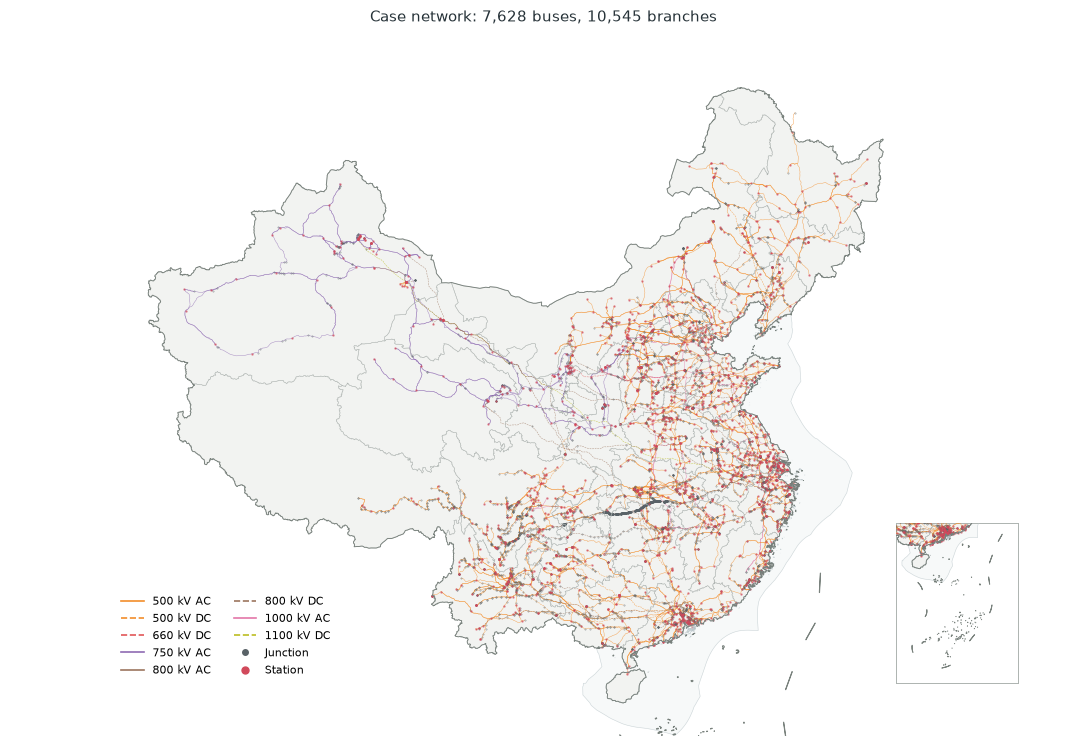

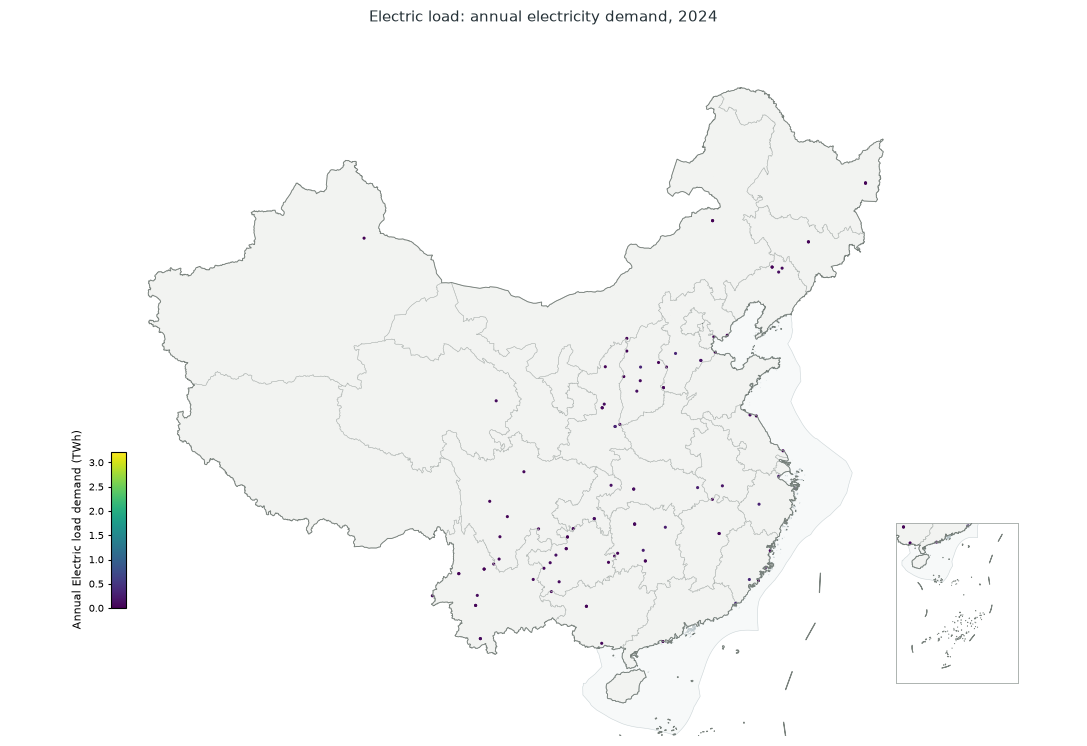

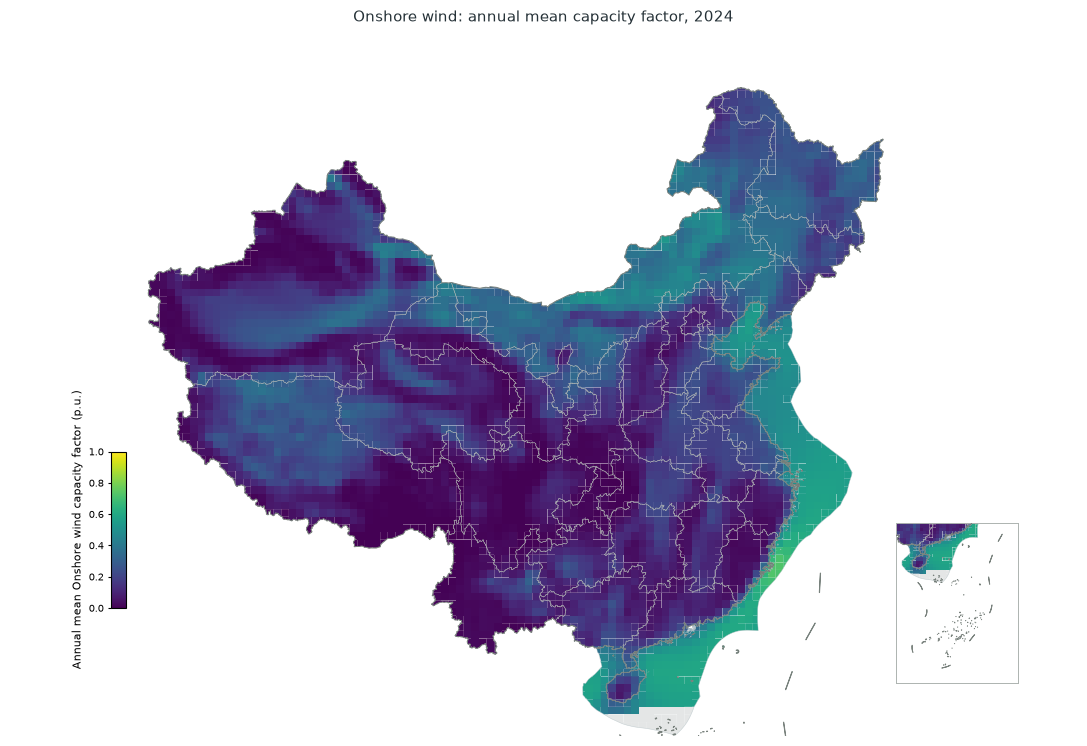

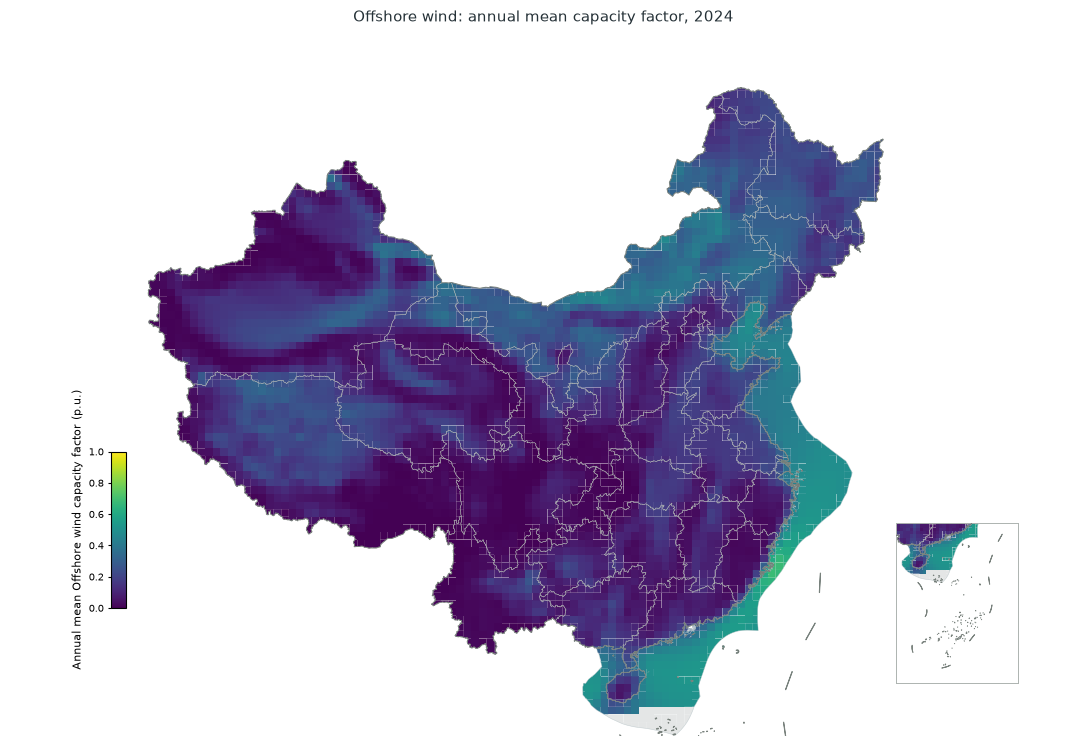

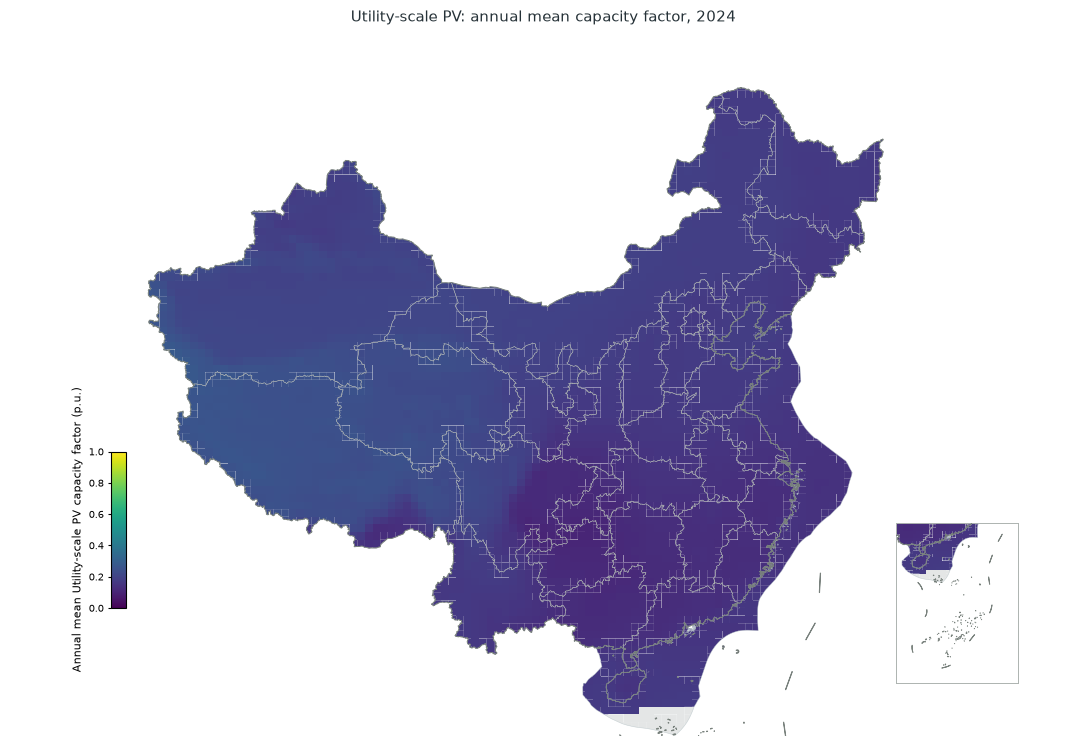

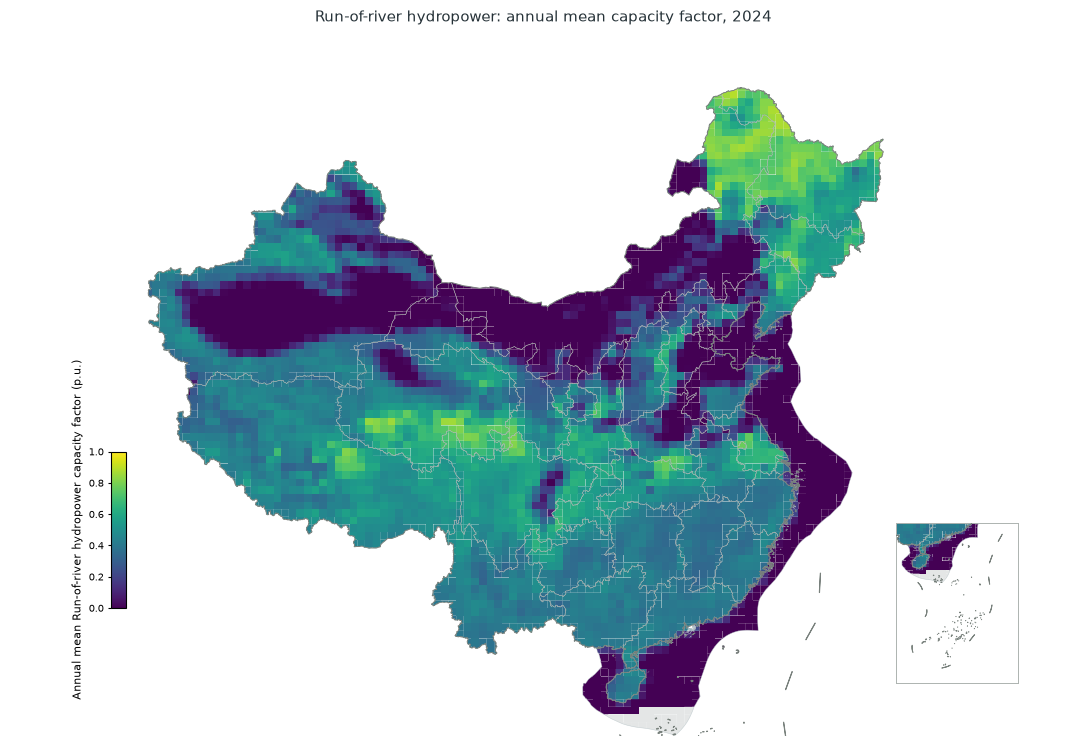

In [11]:
_plot_options = {
    "language": "en",  # "zh" or "en"
    "map_crs": None,  # None uses config/plot.toml
    "china_inset": None,  # None uses config; only national China adds it
    "spatial_levels": None,  # e.g. ["province", "marine_zone"]
}

# Managers and loaded data objects expose the same plot(dataset_id, **kwargs) API.
# The manager reuses its cached complete case instead of loading it for every plot.
def _display_and_close(_figures):
    if not isinstance(_figures, dict):
        _figures = {"figure": _figures}
    for _figure in _figures.values():
        display(_figure)
        plt.close(_figure)
    del _figures
    gc.collect()

for _id in ("spatial", "population", "generator", "storage", "network"):
    _display_and_close(
        case_manager.plot(_id, year=2024, **_plot_options)
    )

# Plot time-series classes one at a time to avoid retaining several large maps.
for _id, _dataset in (("load", case_data.load), ("resource", case_data.resource)):
    for _class_name in _dataset["class"].values.astype(str):
        _display_and_close(
            case_manager.plot(
                _id,
                year=2024,
                class_name=_class_name,
                **_plot_options,
            )
        )

,value
solver_status,ok
termination_condition,optimal
is_optimal,True
objective,4306468340.386916
snapshots,168
load_mwh,204665927.098561
load_shedding_mwh,13279.030913
load_shedding_share,0.000065
storage_discharge_mwh,157548.709567
storage_charge_mwh,207648.001488


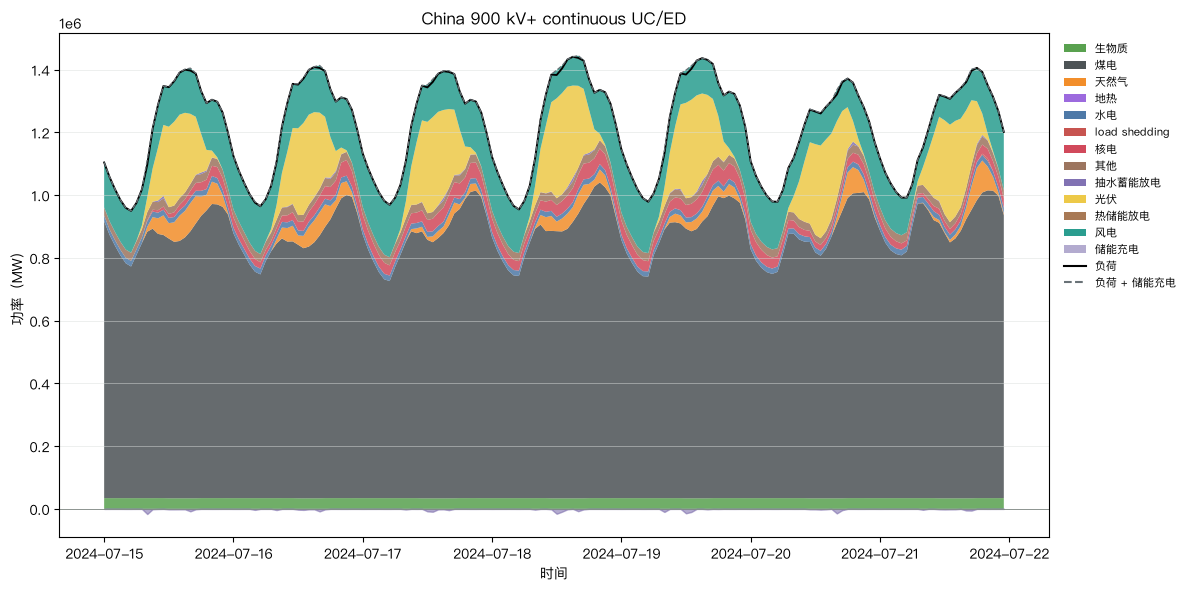

In [10]:
uc_application = UnitCommitmentApplication(case_data, project_root / "config/uc.toml")
# uc_result = uc_application.run()  # Rebuild only after selecting an application-scale case.
uc_result = uc_application.load()
display(uc_result.summary.to_frame())

uc_figure = uc_result.plot(
    start="2024-07-15 00:00",
    end="2024-07-21 23:00",
    title="China 900 kV+ continuous UC/ED",
)
display(uc_figure)
plt.close(uc_figure)


In [26]:
case_data.generator.parameter

,uid,component,name,group,value,unit,match_rank,match_result,match_info,selected_parameter_uid,source_id,source_uid,source_version,reference_url,quality,observed_at
0,case:generator:osm:node:10012472195:bus:ac:500:coal:ultra_supercritical,generator,co2_intensity,environmental,0.3361,tCO2/MWh_th,None,aggregated,aggregated_parameter_records=2,pypsa_technology_costs:coal:CO2 intensity:2025,pypsa_technology_costs,coal:CO2 intensity:2025,07e43575c7996a988c60964d00772376ab9bd10c,Entwicklung der spezifischen Kohlendioxid-Emissionen des deutschen Strommix in den Jahren 1990 - 2018,source,2025
1,case:generator:osm:node:10012472195:bus:ac:500:coal:ultra_supercritical,generator,committable,technical,1.0000,boolean,None,aggregated,aggregated_parameter_records=2,model_assumptions:coal_ge_600:committable,model_assumptions,coal_ge_600:committable,2026-08-04,https://www.dispaset.eu/en/latest/data.html,generic,2026-08-04
2,case:generator:osm:node:10012472195:bus:ac:500:coal:ultra_supercritical,generator,efficiency,technical,0.3560,p.u.,None,aggregated,aggregated_parameter_records=2,pypsa_technology_costs:coal:efficiency:2025,pypsa_technology_costs,coal:efficiency:2025,07e43575c7996a988c60964d00772376ab9bd10c,"Lazard's levelized cost of energy analysis - version 16.0 (2023): https://www.lazard.com/media/typdgxmm/lazards-lcoeplus-april-2023.pdf , pg. 49 (Levelized Cost of Energy - Key Assumptions), accessed: 2023-12-14.",source,2025
3,case:generator:osm:node:10012472195:bus:ac:500:coal:ultra_supercritical,generator,fom,economic,1.3100,%/year,None,aggregated,aggregated_parameter_records=2,pypsa_technology_costs:coal:FOM:2025,pypsa_technology_costs,coal:FOM:2025,07e43575c7996a988c60964d00772376ab9bd10c,"Lazard's levelized cost of energy analysis - version 16.0 (2023): https://www.lazard.com/media/typdgxmm/lazards-lcoeplus-april-2023.pdf , pg. 49 (Levelized Cost of Energy - Key Assumptions), accessed: 2023-12-14.",source,2025
4,case:generator:osm:node:10012472195:bus:ac:500:coal:ultra_supercritical,generator,fuel,environmental,7.8202,EUR/MWh_th,None,aggregated,aggregated_parameter_records=2,pypsa_technology_costs:coal:fuel:2025,pypsa_technology_costs,coal:fuel:2025,07e43575c7996a988c60964d00772376ab9bd10c,"ENTSO-E & ENTSOG TYNDP 2024 Scenarios Inputs Commodity Prices, https://2024-data.entsos-tyndp-scenarios.eu/files/scenarios-inputs/Prices.zip, accessed: 2026-02-03.",source,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54386,case:generator:osm:way:999604996:bus:ac:500:coal:ultra_supercritical,generator,ramp_up_pu_per_hour,technical,0.1000,p.u./h,None,aggregated,aggregated_parameter_records=2,model_assumptions:coal_ge_600:ramp_up_pu_per_hour,model_assumptions,coal_ge_600:ramp_up_pu_per_hour,2026-08-04,https://www.dispaset.eu/en/latest/data.html,generic,2026-08-04
54387,case:generator:osm:way:999604996:bus:ac:500:coal:ultra_supercritical,generator,shutdown_cost_eur_per_mw,economic,0.0000,EUR/MW,None,aggregated,aggregated_parameter_records=2,model_assumptions:coal_ge_600:shutdown_cost_eur_per_mw,model_assumptions,coal_ge_600:shutdown_cost_eur_per_mw,2026-08-04,https://github.com/energy-modelling-toolkit/Dispa-SET/tree/master/Database/PowerPlants,generic,2026-08-04
54388,case:generator:osm:way:999604996:bus:ac:500:coal:ultra_supercritical,generator,startup_cost_eur_per_mw,economic,195.0000,EUR/MW,None,aggregated,aggregated_parameter_records=2,model_assumptions:coal_ge_600:startup_cost_eur_per_mw,model_assumptions,coal_ge_600:startup_cost_eur_per_mw,2026-08-04,https://github.com/energy-modelling-toolkit/Dispa-SET/tree/master/Database/PowerPlants,generic,2026-08-04
54389,case:generator:osm:way:999604996:bus:ac:500:coal:ultra_supercritical,generator,startup_time_h,technical,7.0000,h,None,aggregated,aggregated_parameter_records=2,model_assumptions:coal_ge_600:startup_time_h,model_assumptions,coal_ge_600:startup_time_h,2026-08-04,https://www.dispaset.eu/en/latest/data.html,generic,2026-08-04
